In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [35]:
def load_data(path):
    return pd.read_csv(path, encoding='latin1')

df_printer = load_data("printer_data.csv")
df_service = load_data("service_pack_quote.csv")

df_printer_raw = df_printer.copy()
df_service_raw = df_service.copy()

In [36]:
def explore(df):
    print(df.head())
    print(df.isnull().sum())
    df.info()
    print(df.describe())

explore(df_printer)
explore(df_service)

     guid            make deviceType  speedMono     printDPI  speedColor  \
0  CN0230           Canon   SF Color       33.0   9600 x 600        33.0   
1  KM0122  Konica Minolta   SF Color       35.0    600 x 600        35.0   
2  XE0190           Xerox  MFD Color       23.0    600 x 600        23.0   
3  OK0017             Oki   SF Color       34.0   1200 x 600        32.0   
4  KM0123  Konica Minolta  MFD Color       60.0  3600 x 1200        60.0   

   standardinputcapacity  maximuminputcapacity  hasA3  hasA4  hasColor   scan  \
0                    600                  1100  False   True      True  False   
1                   1150                  2500   True  False      True  False   
2                    251                   500  False   True      True   True   
3                    400                  1460  False   True      True  False   
4                   1500                  7500   True   True      True   True   

     fax listpricecurrent  
0  False          $899.00  


In [37]:
def clean_col_names(df):
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    return df

def clean_price(col):
    col = col.str.replace(",", "", regex=False).str.replace("$", "", regex=False)
    return pd.to_numeric(col, errors="coerce")

In [38]:
df_printer = df_printer_raw.copy()
df_service = df_service_raw.copy()

df_printer = clean_col_names(df_printer)
df_printer = df_printer.drop_duplicates()
df_printer['listpricecurrent'] = clean_price(df_printer['listpricecurrent'])

df_service = clean_col_names(df_service)
df_service['price'] = clean_price(df_service['price'])
df_service = df_service.drop_duplicates()

print(df_printer.dtypes)
print(df_service.dtypes)

guid                         str
make                         str
devicetype                   str
speedmono                float64
printdpi                     str
speedcolor               float64
standardinputcapacity      int64
maximuminputcapacity       int64
hasa3                       bool
hasa4                       bool
hascolor                    bool
scan                        bool
fax                         bool
listpricecurrent         float64
dtype: object
guid                         str
device_product_number        str
price                    float64
dtype: object


In [39]:
def split_dpi(df):
    dpi = df['printdpi'].str.strip().str.upper()
    df['printdpi_x'] = dpi.str.split('X').str[0].str.strip().astype(float)
    df['printdpi_y'] = dpi.str.split('X').str[1].str.strip().astype(float)
    df = df.drop(columns=['printdpi'])
    return df

df_printer = split_dpi(df_printer)
df_printer[['printdpi_x','printdpi_y']].head()

,printdpi_x,printdpi_y
0,9600.0,600.0
1,600.0,600.0
2,600.0,600.0
3,1200.0,600.0
4,3600.0,1200.0


In [40]:
df = pd.merge(df_printer, df_service, on='guid', how='inner')
print(df.shape)
df.head()

(415, 17)


,guid,make,devicetype,speedmono,speedcolor,standardinputcapacity,maximuminputcapacity,hasa3,hasa4,hascolor,scan,fax,listpricecurrent,printdpi_x,printdpi_y,device_product_number,price
0,HP0059,Hewlett-Packard,SF Color,14.0,14.0,125,150,False,True,True,False,False,382.06,4800.0,1200.0,CF147A,85.0
1,HP0063,Hewlett-Packard,MFD Color,14.0,14.0,150,150,False,True,True,True,True,858.35,600.0,600.0,CF145A,85.0
2,HP0270,Hewlett-Packard,SF Color,20.0,15.0,250,550,False,True,True,False,False,229.99,1200.0,1200.0,CV136A,49.0
3,HP0122,Hewlett-Packard,MFD Color,18.0,18.0,250,300,False,True,True,True,True,499.99,600.0,600.0,CE903A,249.0
4,HP0306,Hewlett-Packard,MFD Mono,15.0,0.0,150,150,False,True,False,True,True,850.00,1200.0,1200.0,Q2666A,NaN


In [41]:
def calc_stats(df, group_col, val_col):
    grouped = df.groupby(group_col)[val_col]
    result = grouped.agg(['mean','median'])
    result['mode'] = grouped.apply(lambda x: x.mode().iloc[0] if len(x.mode())>0 else np.nan)
    return result

device_stats = calc_stats(df, 'devicetype', 'listpricecurrent')
service_stats = calc_stats(df, 'devicetype', 'price')

stats_table = pd.concat([device_stats, service_stats], axis=1,
keys=['device_price','service_price'])
print(stats_table)

stats_table.to_csv('devicetype_wise_stats.csv')
print("saved to csv")

           device_price               service_price                
                   mean   median mode          mean   median   mode
devicetype                                                         
MFD Color   5255.578723  2318.28  0.0    863.591176  794.000  259.0
MFD Mono    4406.095844  2241.88  0.0    913.347308  632.775  599.0
SF Color    1594.126082   948.73  0.0    381.865217  223.370  449.0
SF Mono     2057.571529   749.99  0.0    254.048171  159.990   99.0
saved to csv


In [42]:
print(df.isnull().sum())

num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    zeros = (df[c]==0).sum()
    if zeros > 0:
        print(c, "has", zeros, "zeroes")

guid                      0
make                      0
devicetype                0
speedmono                 0
speedcolor                0
standardinputcapacity     0
maximuminputcapacity      0
hasa3                     0
hasa4                     0
hascolor                  0
scan                      0
fax                       0
listpricecurrent         15
printdpi_x                0
printdpi_y                0
device_product_number     0
price                    27
dtype: int64
speedcolor has 176 zeroes
listpricecurrent has 58 zeroes


In [43]:
def fill_na(df, col):
    med = df[col].median()
    df[col] = df[col].fillna(med)
    return df

df = fill_na(df, 'price')
df = fill_na(df, 'listpricecurrent')
print(df.isnull().sum())

guid                     0
make                     0
devicetype               0
speedmono                0
speedcolor               0
standardinputcapacity    0
maximuminputcapacity     0
hasa3                    0
hasa4                    0
hascolor                 0
scan                     0
fax                      0
listpricecurrent         0
printdpi_x               0
printdpi_y               0
device_product_number    0
price                    0
dtype: int64


In [44]:
def get_outlier_count(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr
    count = ((df[col]<low) | (df[col]>high)).sum()
    print(col, ":", count, "outliers")

for c in num_cols:
    get_outlier_count(df, c)

speedmono : 0 outliers
speedcolor : 0 outliers
standardinputcapacity : 31 outliers
maximuminputcapacity : 16 outliers
listpricecurrent : 57 outliers
printdpi_x : 47 outliers
printdpi_y : 1 outliers
price : 19 outliers


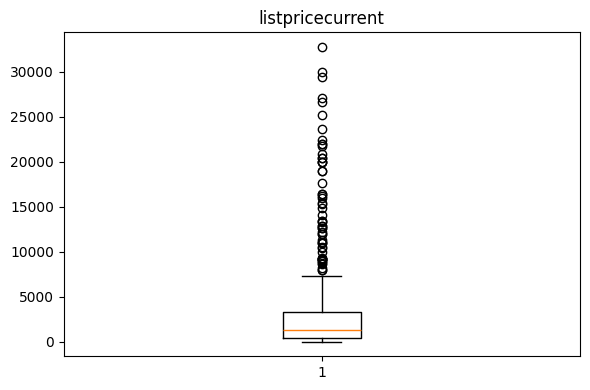

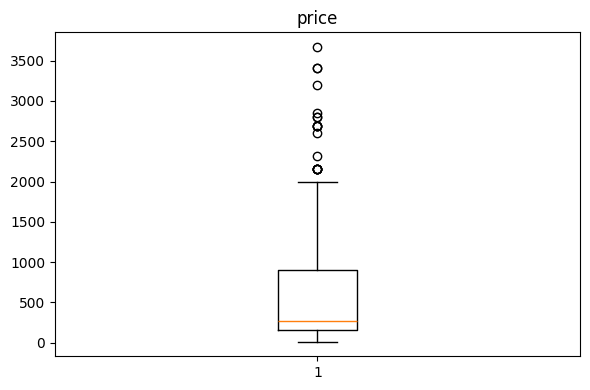

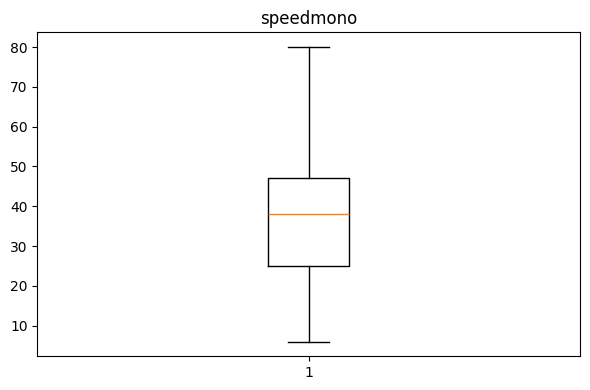

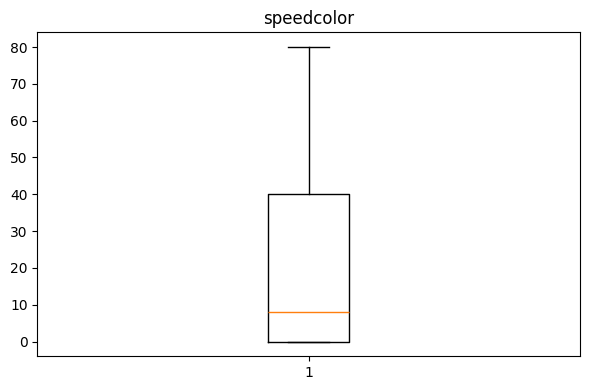

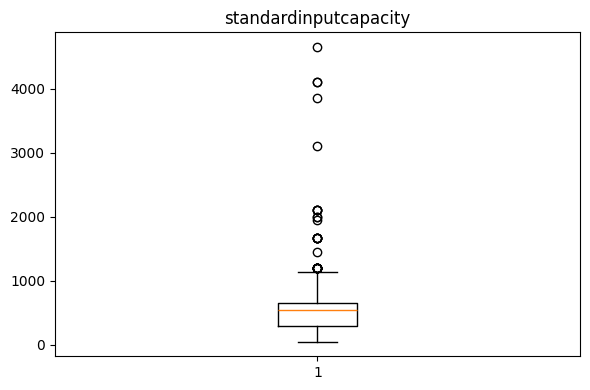

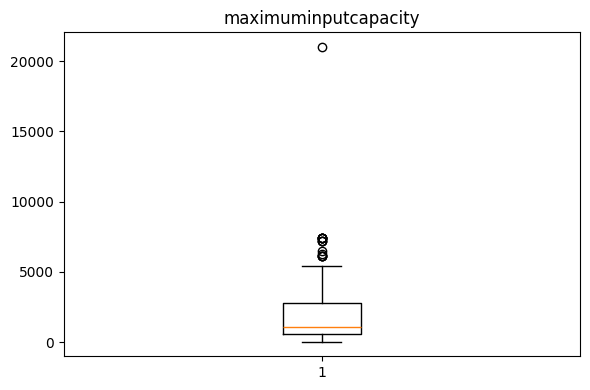

In [45]:
plot_cols = ['listpricecurrent', 'price', 'speedmono', 'speedcolor',
             'standardinputcapacity', 'maximuminputcapacity']

for col in plot_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.tight_layout()
    plt.show()

                       speedmono  speedcolor  standardinputcapacity  \
speedmono                  1.000       0.450                  0.351   
speedcolor                 0.450       1.000                  0.147   
standardinputcapacity      0.351       0.147                  1.000   
maximuminputcapacity       0.543       0.345                  0.511   
listpricecurrent           0.242       0.194                  0.302   
printdpi_x                -0.102       0.058                 -0.113   
printdpi_y                 0.390       0.131                  0.177   
price                      0.413       0.282                  0.595   

                       maximuminputcapacity  listpricecurrent  printdpi_x  \
speedmono                             0.543             0.242      -0.102   
speedcolor                            0.345             0.194       0.058   
standardinputcapacity                 0.511             0.302      -0.113   
maximuminputcapacity                  1.000         

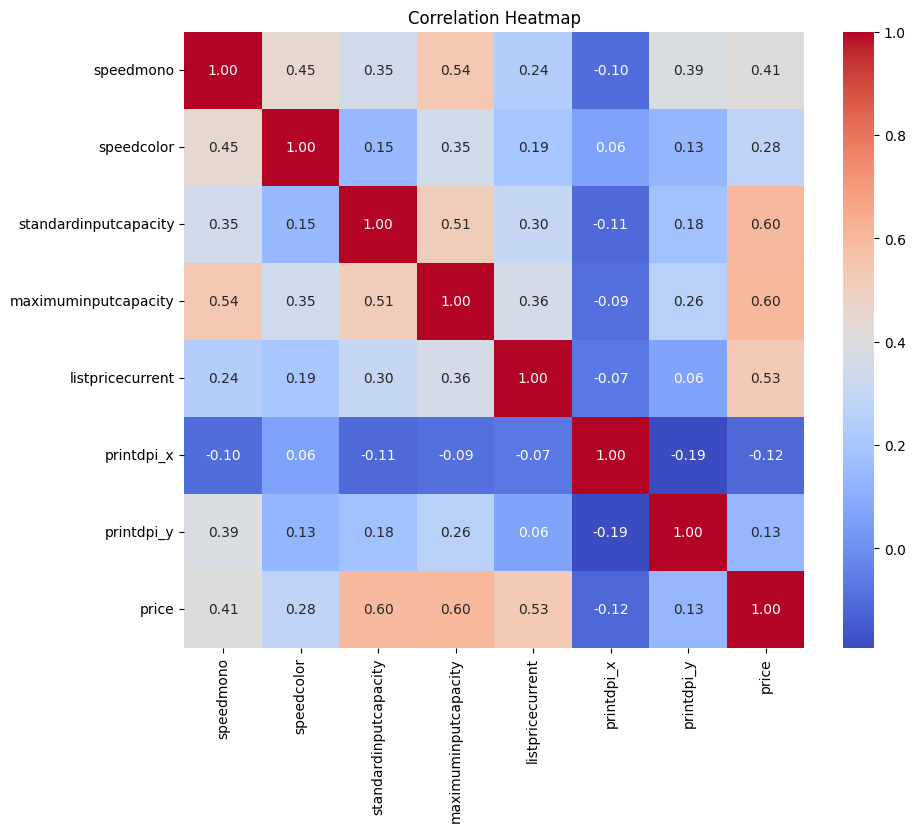

In [46]:
corr = df[num_cols].corr()
print(corr.round(3))

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [47]:
print("total rows:", len(df))
print("unique guids:", df['guid'].nunique())
print("negative device prices:", (df['listpricecurrent']<0).sum())
print("negative service prices:", (df['price']<0).sum())

total rows: 415
unique guids: 401
negative device prices: 0
negative service prices: 0


In [48]:
corr = df[num_cols].corr()
print(corr)

def check_high_correlation(corr, threshold=0.5):
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            val = corr.iloc[i, j]
            if abs(val) > threshold:
                print(cols[i], "<->", cols[j], ":", round(val, 3))

check_high_correlation(corr)

                       speedmono  speedcolor  standardinputcapacity  \
speedmono               1.000000    0.450345               0.350849   
speedcolor              0.450345    1.000000               0.147246   
standardinputcapacity   0.350849    0.147246               1.000000   
maximuminputcapacity    0.543485    0.345064               0.510533   
listpricecurrent        0.242364    0.194326               0.302115   
printdpi_x             -0.102448    0.057947              -0.112573   
printdpi_y              0.389546    0.131316               0.176779   
price                   0.412700    0.282486               0.595171   

                       maximuminputcapacity  listpricecurrent  printdpi_x  \
speedmono                          0.543485          0.242364   -0.102448   
speedcolor                         0.345064          0.194326    0.057947   
standardinputcapacity              0.510533          0.302115   -0.112573   
maximuminputcapacity               1.000000         

In [49]:
cat_cols = df.select_dtypes(include=['str']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['guid','device_product_number']]
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

for c in bool_cols:
    df_model[c] = df_model[c].astype(int)

df_model = df_model.drop(columns=['guid','device_product_number'], errors='ignore')
print(df_model.shape)
print(df_model.columns.tolist())

(415, 19)
['speedmono', 'speedcolor', 'standardinputcapacity', 'maximuminputcapacity', 'hasa3', 'hasa4', 'hascolor', 'scan', 'fax', 'listpricecurrent', 'printdpi_x', 'printdpi_y', 'price', 'make_Hewlett-Packard', 'make_Ricoh', 'make_Samsung', 'devicetype_MFD Mono', 'devicetype_SF Color', 'devicetype_SF Mono']


In [50]:
y = df_model['price']
X = df_model.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("train:", X_train.shape[0], "test:", X_test.shape[0])

train: 290 test: 125


In [51]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Train R2:", round(r2_score(y_train, y_train_pred), 4))
print("Test R2:", round(r2_score(y_test, y_test_pred), 4))
print("Train RMSE:", round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 2))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 2))

Train R2: 0.6732
Test R2: 0.6735
Train RMSE: 374.12
Test RMSE: 397.48


In [52]:
coeff = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_})
coeff = coeff.sort_values('coefficient', ascending=False).reset_index(drop=True)
print("intercept:", round(model.intercept_, 4))
print(coeff)

intercept: -151.5826
                  feature   coefficient
0                   hasa3  5.276495e+02
1    make_Hewlett-Packard  2.336988e+02
2                hascolor  1.264752e+02
3     devicetype_MFD Mono  5.422199e+01
4                    scan  4.626381e+01
5                     fax  4.343564e+01
6            make_Samsung  3.359007e+01
7               speedmono  8.562209e+00
8   standardinputcapacity  3.698087e-01
9    maximuminputcapacity  3.927599e-02
10       listpricecurrent  2.050411e-02
11                  hasa4  3.195488e-11
12             printdpi_x -5.711503e-03
13             printdpi_y -2.455535e-01
14             speedcolor -3.981230e+00
15             make_Ricoh -7.698328e+01
16    devicetype_SF Color -1.327531e+02
17     devicetype_SF Mono -1.806972e+02


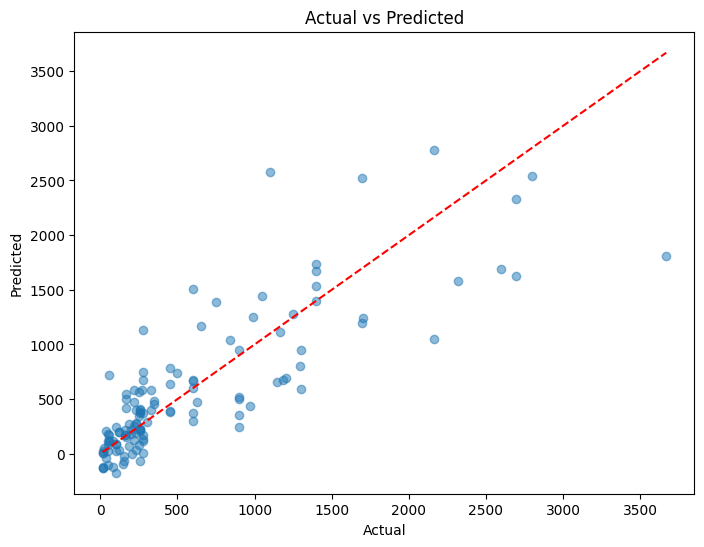

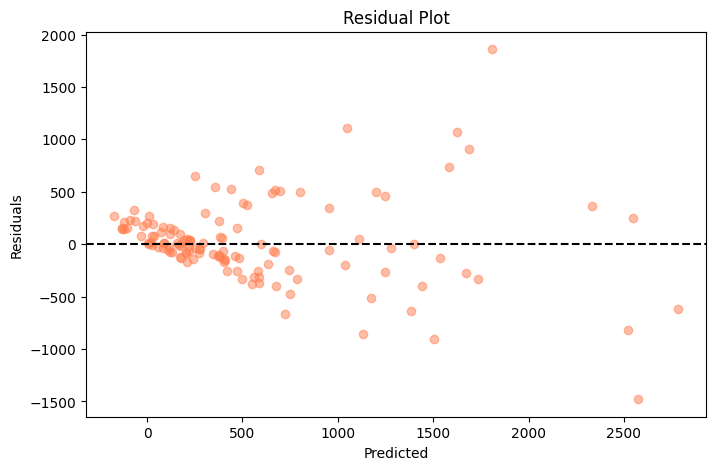

In [53]:
def plot_actual_vs_predicted(y_test, y_test_pred):
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Actual vs Predicted")
    plt.show()

def plot_residuals(y_test, y_test_pred):
    residuals = y_test - y_test_pred
    plt.figure(figsize=(8,5))
    plt.scatter(y_test_pred, residuals, alpha=0.5, color='coral')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.show()

plot_actual_vs_predicted(y_test, y_test_pred)
plot_residuals(y_test, y_test_pred)
